# Phase 3: Biologically Inspired Hidden Perturbations

Models are trained from scratch under each perturbation applied to the **1st hidden layer output**.  
Two model variants are compared:
- **SGD-delay** (solid, filled circles): SNN with learnable axonal delays.
- **SGD** (dashed, × markers): baseline SNN without delays.

Three dataset variants: **Whole** (blue), **Part** (green), **Norm** (red).

## 3A: Per-Spike Jitter

Independent Gaussian noise (σ ms) added to each spike time in the hidden layer output.  
Sweep: σ = 0 → 25 ms.

In [4]:
import json
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

LOG_DIR = pathlib.Path("jitter/log")

COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}


def load_sweep(path: pathlib.Path) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Return (sigma_values, means_pct, stds_pct) from a sweep results JSON."""
    with open(path) as fh:
        raw = json.load(fh)
    sigmas = sorted(int(k) for k in raw)
    means = np.array([raw[str(s)]["mean"] for s in sigmas]) * 100
    stds = np.array([raw[str(s)]["std"] for s in sigmas]) * 100
    return sigmas, means, stds

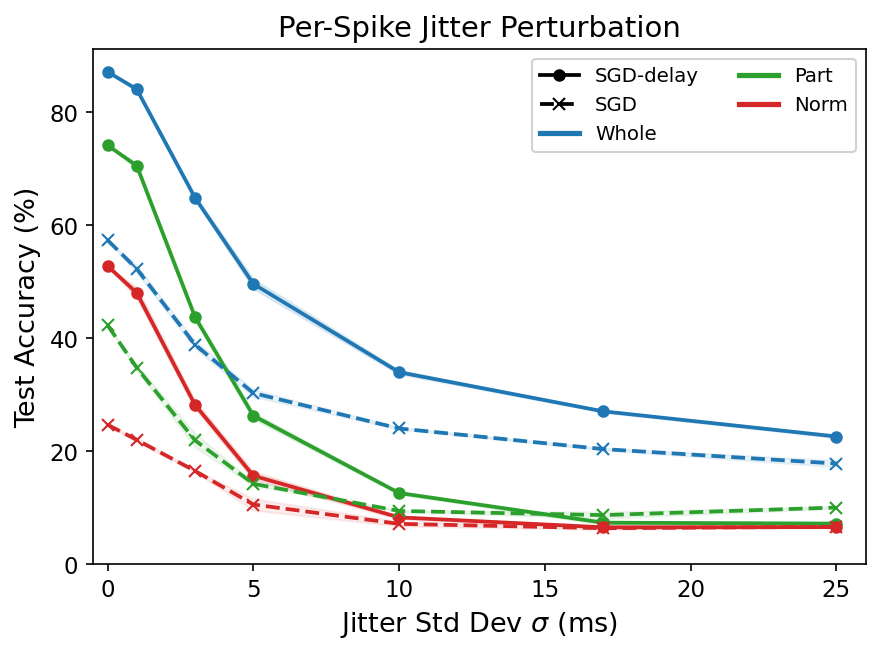

In [5]:
# ---------- Load sweep results ----------
whole_del_s, whole_del_m, whole_del_std = load_sweep(LOG_DIR / "jitter_whole_delay_input_perturbation_results.json")
whole_nod_s, whole_nod_m, whole_nod_std = load_sweep(LOG_DIR / "jitter_whole_nodelay_input_perturbation_results.json")
part_del_s,  part_del_m,  part_del_std  = load_sweep(LOG_DIR / "jitter_part_delay_input_perturbation_results.json")
part_nod_s,  part_nod_m,  part_nod_std  = load_sweep(LOG_DIR / "jitter_part_nodelay_input_perturbation_results.json")
norm_del_s,  norm_del_m,  norm_del_std  = load_sweep(LOG_DIR / "jitter_norm_delay_input_perturbation_results.json")
norm_nod_s,  norm_nod_m,  norm_nod_std  = load_sweep(LOG_DIR / "jitter_norm_nodelay_input_perturbation_results.json")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(6, 4.5))

# SGD-delay (solid, filled circles)
for s, m, std, key in [
    (whole_del_s, whole_del_m, whole_del_std, "Whole"),
    (part_del_s,  part_del_m,  part_del_std,  "Part"),
    (norm_del_s,  norm_del_m,  norm_del_std,  "Norm"),
]:
    ax.plot(s, m, "o-", color=COLORS[key], markersize=5, linewidth=1.8)
    ax.fill_between(s, m - std, m + std, color=COLORS[key], alpha=0.12)

# SGD (dashed, × markers)
for s, m, std, key in [
    (whole_nod_s, whole_nod_m, whole_nod_std, "Whole"),
    (part_nod_s,  part_nod_m,  part_nod_std,  "Part"),
    (norm_nod_s,  norm_nod_m,  norm_nod_std,  "Norm"),
]:
    ax.plot(s, m, "x--", color=COLORS[key], markersize=6, linewidth=1.8)
    ax.fill_between(s, m - std, m + std, color=COLORS[key], alpha=0.08)

ax.set_title("Per-Spike Jitter Perturbation")
ax.set_xlabel(r"Jitter Std Dev $\sigma$ (ms)")
ax.set_ylabel("Test Accuracy (%)")
ax.set_xlim(-0.5, 26)
ax.set_ylim(0, None)

# ---------- Legend ----------
h_delay = mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                         markersize=5, linewidth=1.8, label="SGD-delay")
h_sgd   = mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                         markersize=6, linewidth=1.8, label="SGD")
h_whole = mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole")
h_part  = mlines.Line2D([], [], color=COLORS["Part"],  linewidth=2.5, label="Part")
h_norm  = mlines.Line2D([], [], color=COLORS["Norm"],  linewidth=2.5, label="Norm")

ax.legend(handles=[h_delay, h_sgd, h_whole, h_part, h_norm],
          loc="upper right", framealpha=0.9, ncol=2)

fig.tight_layout()
#plt.savefig("jitter_perturbation_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 3B: Per-Neuron Shift

The same Gaussian offset is applied to **all spikes from a given hidden neuron**, preserving intra-neuron ISI while disrupting cross-neuron timing.  
Sweep: σ = 0 → 25 ms.

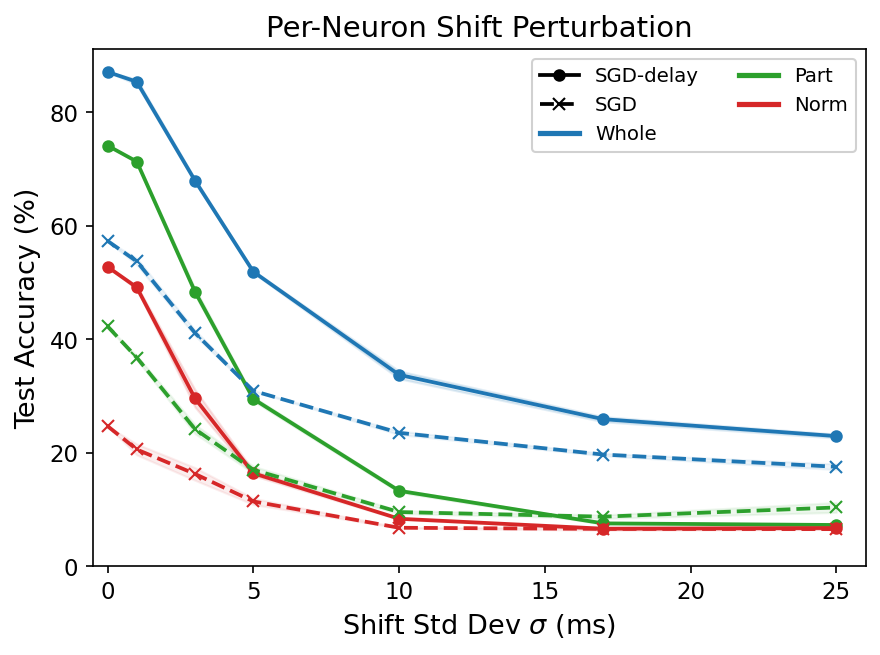

In [6]:
SHIFT_LOG = pathlib.Path("shift/log")

# ---------- Load sweep results ----------
s_whole_del_s, s_whole_del_m, s_whole_del_std = load_sweep(SHIFT_LOG / "shift_whole_delay_input_perturbation_results.json")
s_whole_nod_s, s_whole_nod_m, s_whole_nod_std = load_sweep(SHIFT_LOG / "shift_whole_nodelay_input_perturbation_results.json")
s_part_del_s,  s_part_del_m,  s_part_del_std  = load_sweep(SHIFT_LOG / "shift_part_delay_input_perturbation_results.json")
s_part_nod_s,  s_part_nod_m,  s_part_nod_std  = load_sweep(SHIFT_LOG / "shift_part_nodelay_input_perturbation_results.json")
s_norm_del_s,  s_norm_del_m,  s_norm_del_std  = load_sweep(SHIFT_LOG / "shift_norm_delay_input_perturbation_results.json")
s_norm_nod_s,  s_norm_nod_m,  s_norm_nod_std  = load_sweep(SHIFT_LOG / "shift_norm_nodelay_input_perturbation_results.json")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(6, 4.5))

# SGD-delay (solid, filled circles)
for s, m, std, key in [
    (s_whole_del_s, s_whole_del_m, s_whole_del_std, "Whole"),
    (s_part_del_s,  s_part_del_m,  s_part_del_std,  "Part"),
    (s_norm_del_s,  s_norm_del_m,  s_norm_del_std,  "Norm"),
]:
    ax.plot(s, m, "o-", color=COLORS[key], markersize=5, linewidth=1.8)
    ax.fill_between(s, m - std, m + std, color=COLORS[key], alpha=0.12)

# SGD (dashed, × markers)
for s, m, std, key in [
    (s_whole_nod_s, s_whole_nod_m, s_whole_nod_std, "Whole"),
    (s_part_nod_s,  s_part_nod_m,  s_part_nod_std,  "Part"),
    (s_norm_nod_s,  s_norm_nod_m,  s_norm_nod_std,  "Norm"),
]:
    ax.plot(s, m, "x--", color=COLORS[key], markersize=6, linewidth=1.8)
    ax.fill_between(s, m - std, m + std, color=COLORS[key], alpha=0.08)

ax.set_title("Per-Neuron Shift Perturbation")
ax.set_xlabel(r"Shift Std Dev $\sigma$ (ms)")
ax.set_ylabel("Test Accuracy (%)")
ax.set_xlim(-0.5, 26)
ax.set_ylim(0, None)

# ---------- Legend ----------
h_delay = mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                         markersize=5, linewidth=1.8, label="SGD-delay")
h_sgd   = mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                         markersize=6, linewidth=1.8, label="SGD")
h_whole = mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole")
h_part  = mlines.Line2D([], [], color=COLORS["Part"],  linewidth=2.5, label="Part")
h_norm  = mlines.Line2D([], [], color=COLORS["Norm"],  linewidth=2.5, label="Norm")

ax.legend(handles=[h_delay, h_sgd, h_whole, h_part, h_norm],
          loc="upper right", framealpha=0.9, ncol=2)

fig.tight_layout()
#plt.savefig("shift_perturbation_results.png", dpi=150, bbox_inches="tight")
plt.show()

## 3C: Spike Deletion

Each spike in the 1st hidden layer output is independently dropped with
probability $p_d$, reducing total spike count while preserving the
timing of survivors. Sweep: $p_d$ = 0.0 → 0.8.

Results below come from the **eval-only** protocol — for each
`(dataset, delay-mode)` we evaluate the shared clean-trained jitter
checkpoint across the $p_d$ sweep.

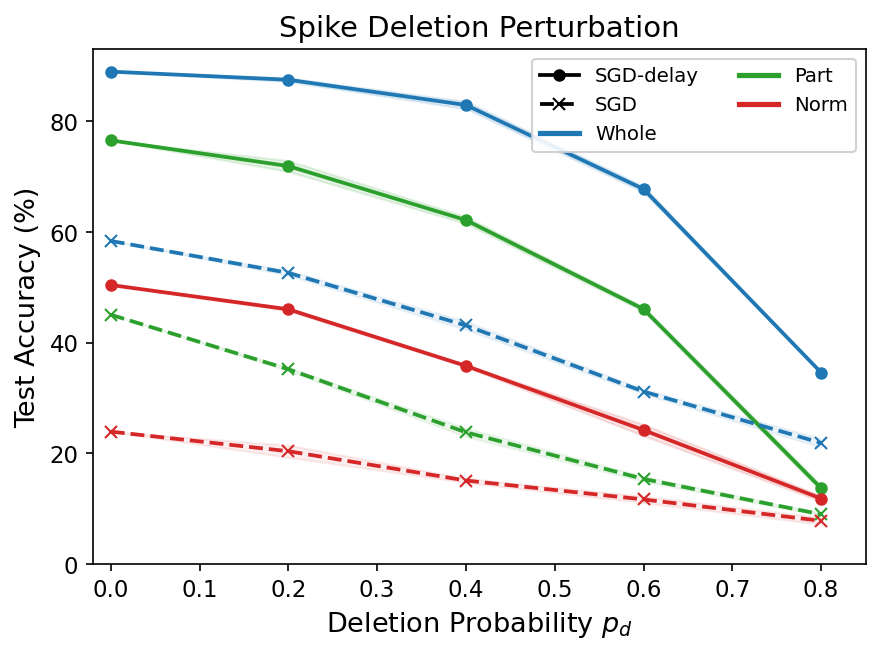

In [7]:
DELETION_LOG = pathlib.Path("deletion/log")


def load_sweep_float(path: pathlib.Path) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Like load_sweep but treats result-keys as floats (for p_d / f values)."""
    with open(path) as fh:
        raw = json.load(fh)
    items = sorted(((float(k), k) for k in raw), key=lambda p: p[0])
    xs = [p[0] for p in items]
    means = np.array([raw[k]["mean"] for _, k in items]) * 100
    stds  = np.array([raw[k]["std"]  for _, k in items]) * 100
    return xs, means, stds


# ---------- Load sweep results (eval-only protocol) ----------
d_whole_del_x, d_whole_del_m, d_whole_del_std = load_sweep_float(
    DELETION_LOG / "deletion_whole_delay_input_perturbation_results.json")
d_whole_nod_x, d_whole_nod_m, d_whole_nod_std = load_sweep_float(
    DELETION_LOG / "deletion_whole_nodelay_input_perturbation_results.json")
d_part_del_x,  d_part_del_m,  d_part_del_std  = load_sweep_float(
    DELETION_LOG / "deletion_part_delay_input_perturbation_results.json")
d_part_nod_x,  d_part_nod_m,  d_part_nod_std  = load_sweep_float(
    DELETION_LOG / "deletion_part_nodelay_input_perturbation_results.json")
d_norm_del_x,  d_norm_del_m,  d_norm_del_std  = load_sweep_float(
    DELETION_LOG / "deletion_norm_delay_input_perturbation_results.json")
d_norm_nod_x,  d_norm_nod_m,  d_norm_nod_std  = load_sweep_float(
    DELETION_LOG / "deletion_norm_nodelay_input_perturbation_results.json")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(6, 4.5))

# SGD-delay (solid, filled circles)
for xs, m, std, key in [
    (d_whole_del_x, d_whole_del_m, d_whole_del_std, "Whole"),
    (d_part_del_x,  d_part_del_m,  d_part_del_std,  "Part"),
    (d_norm_del_x,  d_norm_del_m,  d_norm_del_std,  "Norm"),
]:
    ax.plot(xs, m, "o-", color=COLORS[key], markersize=5, linewidth=1.8)
    ax.fill_between(xs, m - std, m + std, color=COLORS[key], alpha=0.12)

# SGD (dashed, x markers)
for xs, m, std, key in [
    (d_whole_nod_x, d_whole_nod_m, d_whole_nod_std, "Whole"),
    (d_part_nod_x,  d_part_nod_m,  d_part_nod_std,  "Part"),
    (d_norm_nod_x,  d_norm_nod_m,  d_norm_nod_std,  "Norm"),
]:
    ax.plot(xs, m, "x--", color=COLORS[key], markersize=6, linewidth=1.8)
    ax.fill_between(xs, m - std, m + std, color=COLORS[key], alpha=0.08)

ax.set_title("Spike Deletion Perturbation")
ax.set_xlabel(r"Deletion Probability $p_d$")
ax.set_ylabel("Test Accuracy (%)")
ax.set_xlim(-0.02, 0.85)
ax.set_ylim(0, None)

# ---------- Legend ----------
h_delay = mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                         markersize=5, linewidth=1.8, label="SGD-delay")
h_sgd   = mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                         markersize=6, linewidth=1.8, label="SGD")
h_whole = mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole")
h_part  = mlines.Line2D([], [], color=COLORS["Part"],  linewidth=2.5, label="Part")
h_norm  = mlines.Line2D([], [], color=COLORS["Norm"],  linewidth=2.5, label="Norm")

ax.legend(handles=[h_delay, h_sgd, h_whole, h_part, h_norm],
          loc="upper right", framealpha=0.9, ncol=2)

fig.tight_layout()
#plt.savefig("deletion_perturbation_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Phase 4: Time Reversal at Hidden Layer

The pre-trained 2-hidden-layer SNN is evaluated under two conditions at
each hidden perturbation level $f$:

- **No reversal** (baseline): a fraction $f$ of each neuron's hidden spikes
  is relocated to random empty time bins, preserving spike count.
- **With reversal**: in addition to the $f$-perturbation, each sample's
  hidden spike trains are time-reversed within the sample-wide active
  window. This preserves spike count, per-neuron rate, intra-neuron ISI,
  and cross-neuron coincidence — only causal temporal order is flipped.

Comparing the two reveals how much downstream layers rely on causal
temporal order in the hidden representation. Sweep: $f$ = 0.0 → 1.0.

## 4A: Hidden-Layer Time Reversal

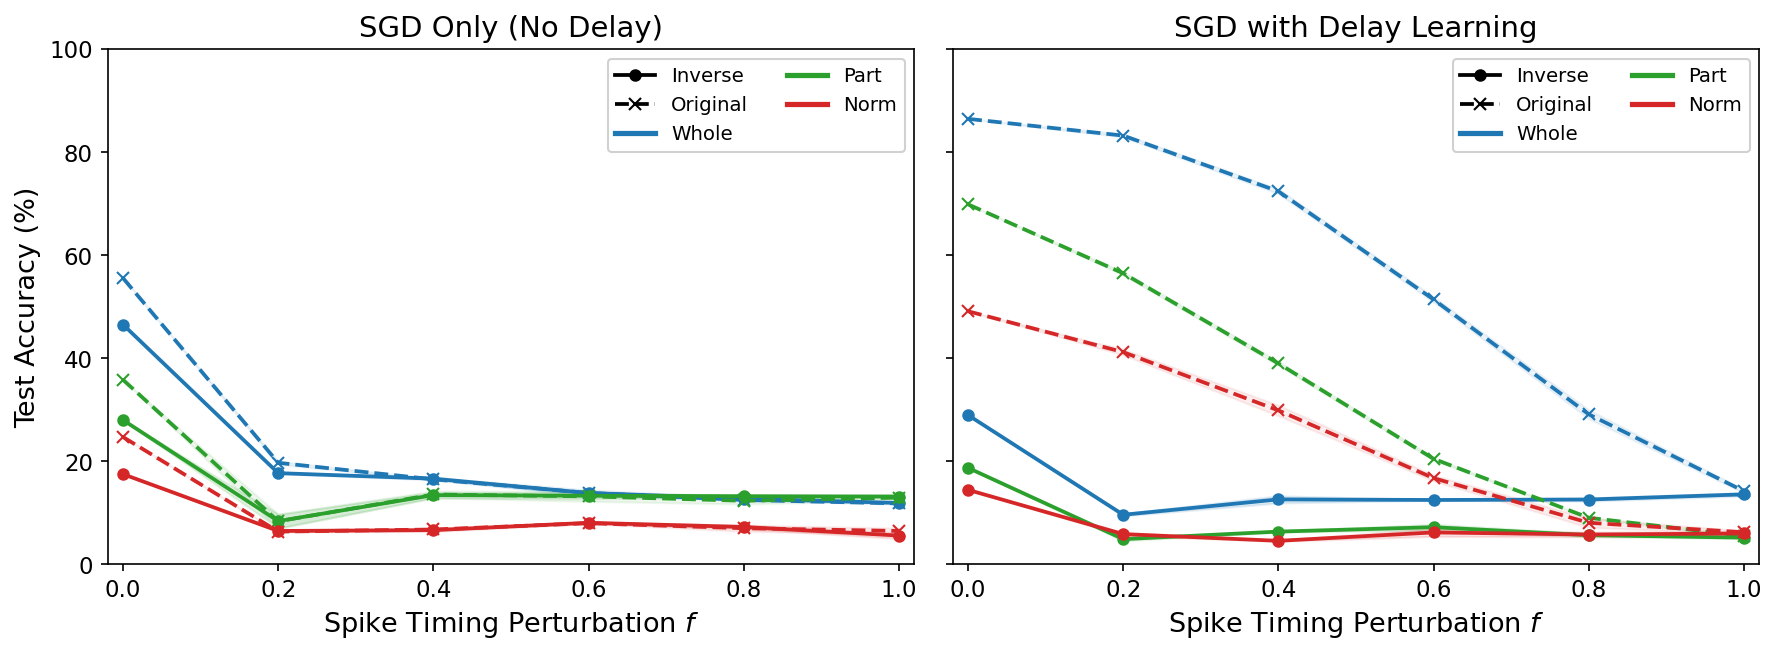

In [8]:
INVERSE_LOG = pathlib.Path("inverse/log")

INVERSE_FILES = {
    ("Whole", True):  INVERSE_LOG / "shd_whole_delay_input_reversal_sweep_results.json",
    ("Whole", False): INVERSE_LOG / "shd_whole_nodelay_input_reversal_sweep_results.json",
    ("Part",  True):  INVERSE_LOG / "shd_part_delay_input_reversal_sweep_results.json",
    ("Part",  False): INVERSE_LOG / "shd_part_nodelay_input_reversal_sweep_results.json",
    ("Norm",  True):  INVERSE_LOG / "shd_norm_delay_input_reversal_sweep_results.json",
    ("Norm",  False): INVERSE_LOG / "shd_norm_nodelay_input_reversal_sweep_results.json",
}


def load_reversal_sweep(
    path: pathlib.Path, condition: str,
) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Load one condition ('no_reversal' or 'reversal') from an inverse JSON."""
    with open(path) as fh:
        raw = json.load(fh)
    cond = raw[condition]
    items = sorted(((float(k), k) for k in cond), key=lambda p: p[0])
    xs = [p[0] for p in items]
    means = np.array([cond[k]["mean"] for _, k in items]) * 100
    stds  = np.array([cond[k]["std"]  for _, k in items]) * 100
    return xs, means, stds


# ---------- Plot: split by delay mode; overlay Inverse vs Original ----------
# Style matches the Beyond Rate paper figure (panel (b)/(c)):
#   Inverse  (== reversal,    solid line + filled circle marker)
#   Original (== no_reversal, dashed line + 'x' marker)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, use_delay, panel_title in zip(
    axes,
    [False, True],
    ["SGD Only (No Delay)", "SGD with Delay Learning"],
):
    for key in ["Whole", "Part", "Norm"]:
        path = INVERSE_FILES[(key, use_delay)]

        # Inverse (reversal) — solid line, filled circle marker
        xs, m, std = load_reversal_sweep(path, "reversal")
        ax.plot(xs, m, "o-", color=COLORS[key], markersize=5, linewidth=1.8)
        ax.fill_between(xs, m - std, m + std, color=COLORS[key], alpha=0.12)

        # Original (no_reversal) — dashed line, 'x' marker
        xs, m, std = load_reversal_sweep(path, "no_reversal")
        ax.plot(xs, m, "x--", color=COLORS[key], markersize=6, linewidth=1.8)
        ax.fill_between(xs, m - std, m + std, color=COLORS[key], alpha=0.08)

    ax.set_title(panel_title)
    ax.set_xlabel(r"Spike Timing Perturbation $f$")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0, 100)
    ax.grid(False)

axes[0].set_ylabel("Test Accuracy (%)")

# ---------- Legend on each panel (matching the reference figure) ----------
h_inverse  = mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                           markersize=5, linewidth=1.8, label="Inverse")
h_original = mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                           markersize=6, linewidth=1.8, label="Original")
h_whole = mlines.Line2D([], [], color=COLORS["Whole"], linewidth=2.5, label="Whole")
h_part  = mlines.Line2D([], [], color=COLORS["Part"],  linewidth=2.5, label="Part")
h_norm  = mlines.Line2D([], [], color=COLORS["Norm"],  linewidth=2.5, label="Norm")

for ax in axes:
    ax.legend(handles=[h_inverse, h_original, h_whole, h_part, h_norm],
              loc="upper right", framealpha=0.9, ncol=2)

fig.tight_layout()
#plt.savefig("inverse_reversal_results.png", dpi=150, bbox_inches="tight")
plt.show()